In [1]:
from pathlib import Path

BASE_DIR = Path("e8_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e8_artifacts/logs
/content/e8_artifacts/tables
/content/e8_artifacts/figures
/content/e8_artifacts/reports


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
RUSENTITWEET_BERT_PATH = "/content/drive/MyDrive/rubert_tiny2_sentiment_model_tuned"
RUSENTIMENT_BERT_PATH = "/content/drive/MyDrive/rusentiment_rubert_tiny_tuned_model"

In [5]:
from pathlib import Path

print("RuSentiTweet model exists:", Path(RUSENTITWEET_BERT_PATH).exists())
print("RuSentiment model exists:", Path(RUSENTIMENT_BERT_PATH).exists())

RuSentiTweet model exists: True
RuSentiment model exists: True


In [6]:
import pandas as pd

# RuSentiTweet
RST_TRAIN_PATH = "train_final.csv"
RST_TEST_PATH = "test_final.csv"

# RuSentiment
RS_TRAIN_PATH = "rusentiment_train_final.csv"
RS_TEST_PATH = "rusentiment_test_final.csv"

rst_train_df = pd.read_csv(RST_TRAIN_PATH)
rst_test_df = pd.read_csv(RST_TEST_PATH)

rs_train_df = pd.read_csv(RS_TRAIN_PATH)
rs_test_df = pd.read_csv(RS_TEST_PATH)

print("RuSentiTweet train:", rst_train_df.shape)
print("RuSentiTweet test:", rst_test_df.shape)
print("RuSentiment train:", rs_train_df.shape)
print("RuSentiment test:", rs_test_df.shape)

RuSentiTweet train: (7957, 3)
RuSentiTweet test: (2211, 3)
RuSentiment train: (18920, 2)
RuSentiment test: (2214, 2)


In [7]:
print("RuSentiTweet train columns:", rst_train_df.columns.tolist())
print("RuSentiTweet test columns:", rst_test_df.columns.tolist())
print("RuSentiment train columns:", rs_train_df.columns.tolist())
print("RuSentiment test columns:", rs_test_df.columns.tolist())

RuSentiTweet train columns: ['text', 'label', 'id']
RuSentiTweet test columns: ['text', 'label', 'id']
RuSentiment train columns: ['label', 'text']
RuSentiment test columns: ['label', 'text']


In [8]:
import json

SEED = 42
LABEL_ORDER = ["negative", "neutral", "positive"]

E8_CONFIG = {
    "experiment": "E8 cross-dataset transfer",
    "seed": SEED,
    "label_order": LABEL_ORDER,
    "directions": [
        "RuSentiTweet -> RuSentiment",
        "RuSentiment -> RuSentiTweet"
    ],
    "classical_model": {
        "model": "SGDClassifier hinge",
        "representation": {
            "type": "TfidfVectorizer",
            "lowercase": True,
            "analyzer": "char_wb",
            "ngram_range": (3, 5),
            "min_df": 2,
            "max_df": 0.95
        }
    },
    "bert_models": {
        "rusentitweet_tuned_path": RUSENTITWEET_BERT_PATH,
        "rusentiment_tuned_path": RUSENTIMENT_BERT_PATH
    }
}

with open(LOG_DIR / "e8_config.json", "w", encoding="utf-8") as f:
    json.dump(E8_CONFIG, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "e8_config.json")

Saved: e8_artifacts/logs/e8_config.json


In [9]:
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [10]:
def run_classical_cross_dataset(
    source_name,
    target_name,
    source_train_df,
    target_test_df,
    report_filename,
    figure_filename
):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.95
    )

    X_train = vectorizer.fit_transform(source_train_df["text"])
    y_train = source_train_df["label"].copy()

    X_test = vectorizer.transform(target_test_df["text"])
    y_test = target_test_df["label"].copy()

    model = SGDClassifier(
        loss="hinge",
        max_iter=1000,
        tol=1e-3,
        random_state=SEED
    )

    start_time = time.time()
    model.fit(X_train, y_train)
    runtime_sec = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_test, y_pred, average="macro")

    report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report_text)

    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"{source_name} → {target_name}\nClassical confusion matrix")
    plt.tight_layout()
    plt.savefig(FIG_DIR / figure_filename, dpi=300, bbox_inches="tight")
    plt.show()

    result = {
        "source_dataset": source_name,
        "target_dataset": target_name,
        "model_family": "classical",
        "model": "SGDClassifier hinge + char TF-IDF",
        "representation": "char TF-IDF (3,5)",
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "runtime_sec": round(runtime_sec, 4),
        "seed": SEED
    }

    return result, y_pred, report_text

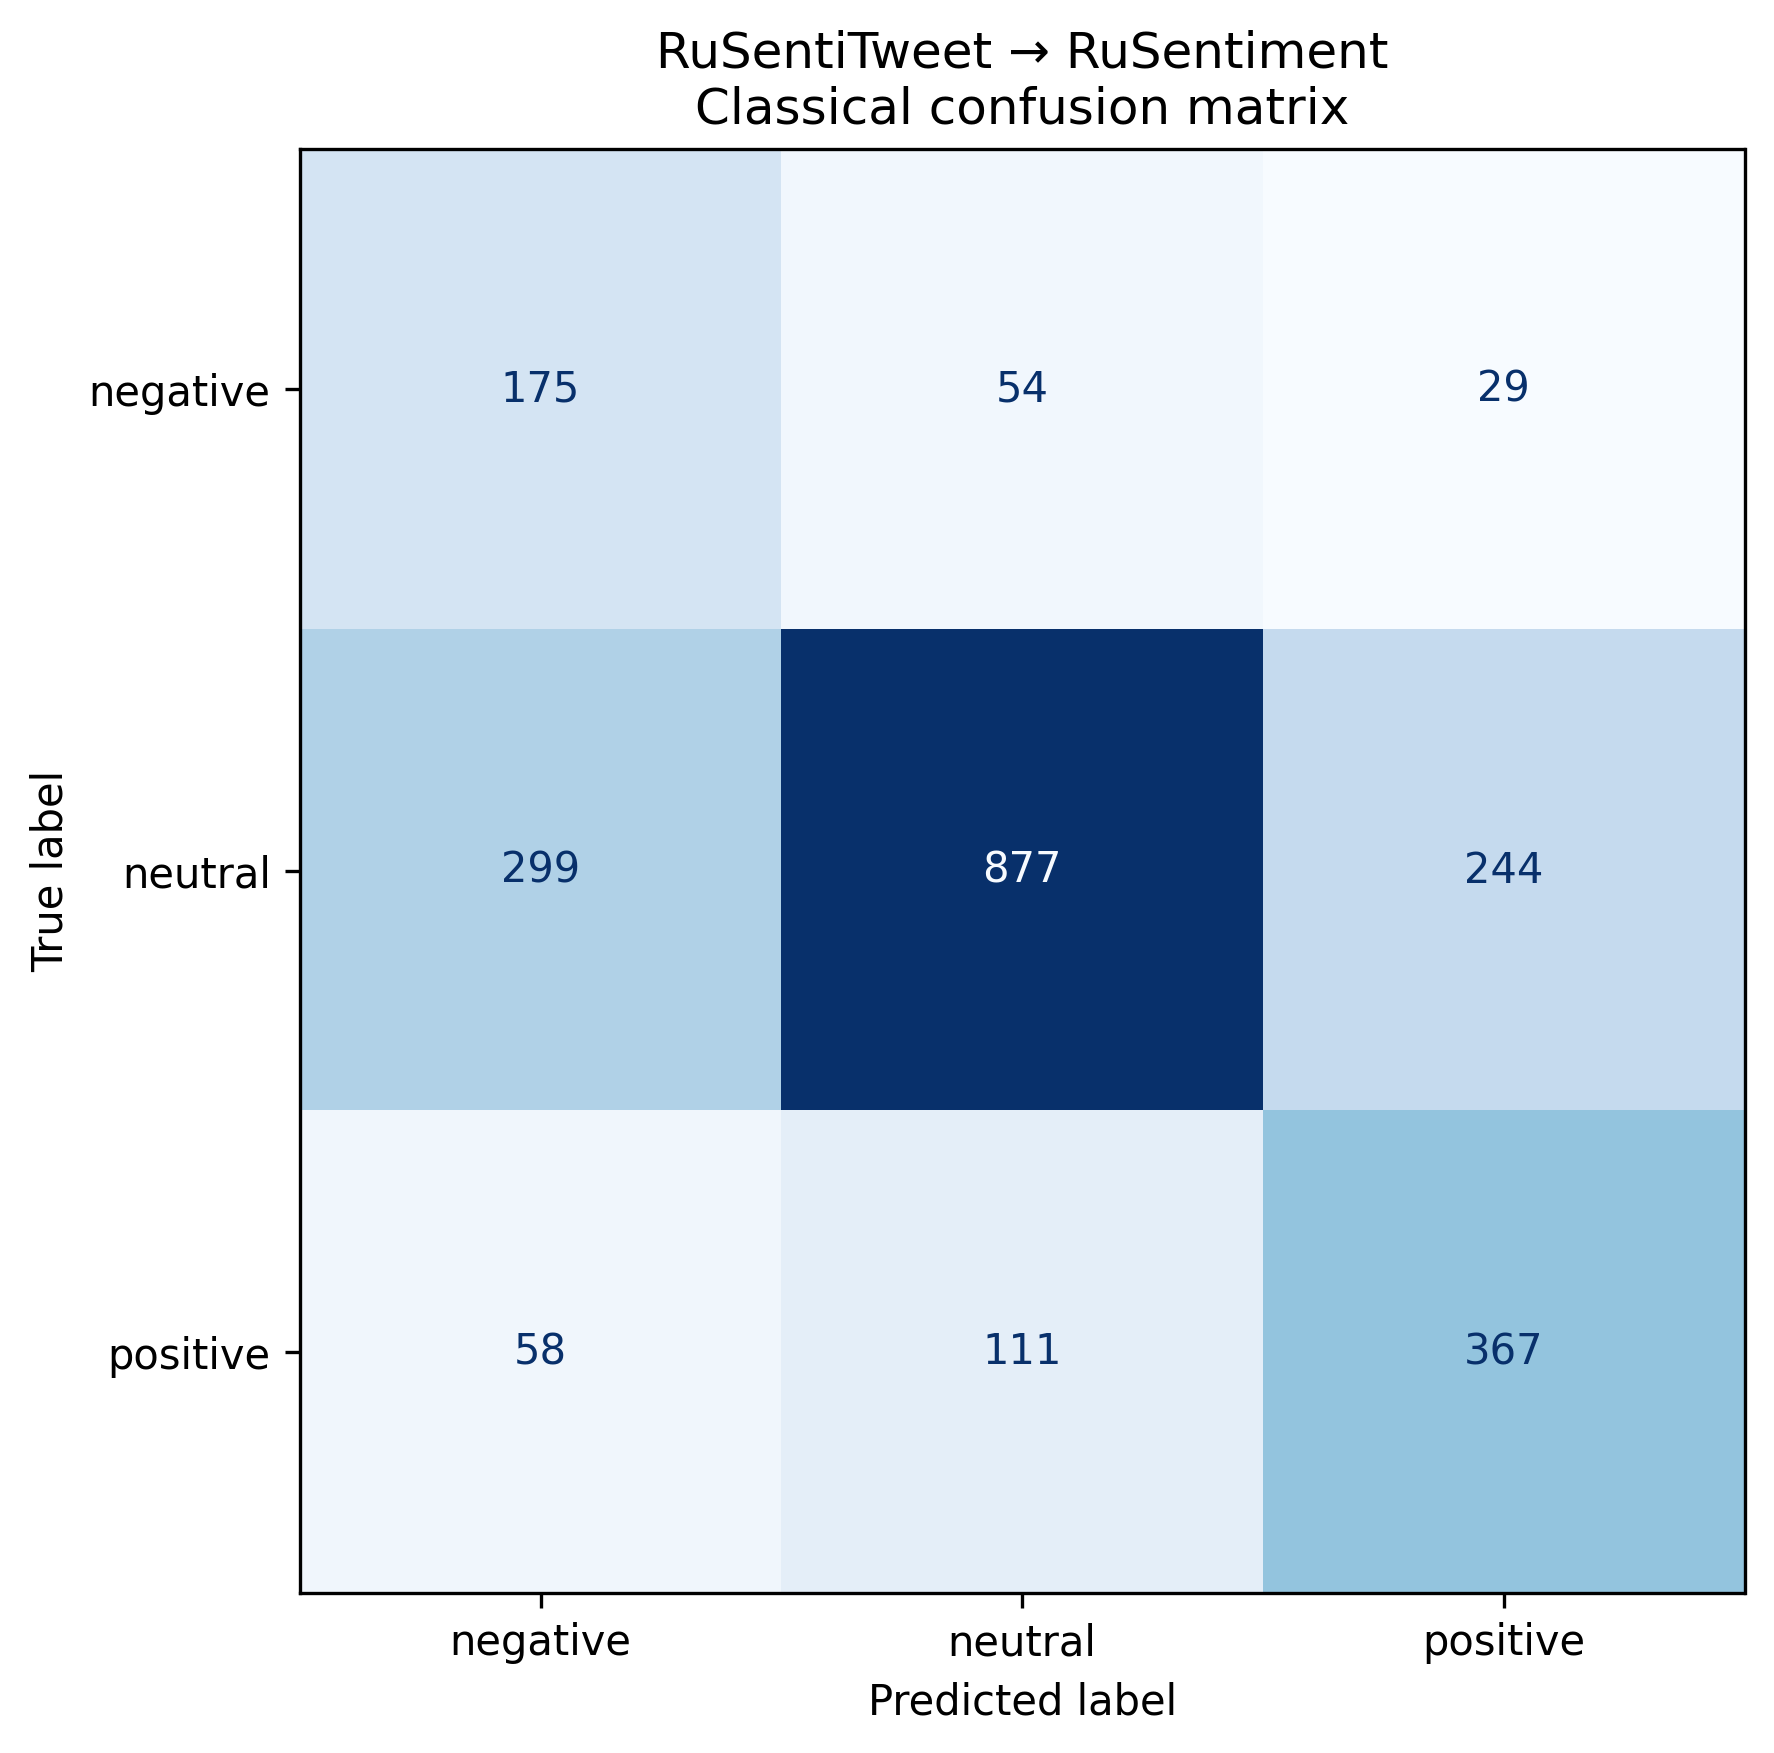

{'source_dataset': 'RuSentiTweet', 'target_dataset': 'RuSentiment', 'model_family': 'classical', 'model': 'SGDClassifier hinge + char TF-IDF', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6409, 'precision_weighted': 0.717, 'recall_weighted': 0.6409, 'weighted_f1': 0.6597, 'macro_f1': 0.5932, 'runtime_sec': 1.883, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.3289    0.6783    0.4430       258
     neutral     0.8417    0.6176    0.7124      1420
    positive     0.5734    0.6847    0.6241       536

    accuracy                         0.6409      2214
   macro avg     0.5813    0.6602    0.5932      2214
weighted avg     0.7170    0.6409    0.6597      2214



In [11]:
e8_results = []

res_classical_rst_to_rs, pred_classical_rst_to_rs, rep_classical_rst_to_rs = run_classical_cross_dataset(
    source_name="RuSentiTweet",
    target_name="RuSentiment",
    source_train_df=rst_train_df,
    target_test_df=rs_test_df,
    report_filename="classification_report_rst_to_rs_classical.txt",
    figure_filename="rst_to_rs_classical_confusion_matrix.png"
)

e8_results.append(res_classical_rst_to_rs)

print(res_classical_rst_to_rs)
print(rep_classical_rst_to_rs)

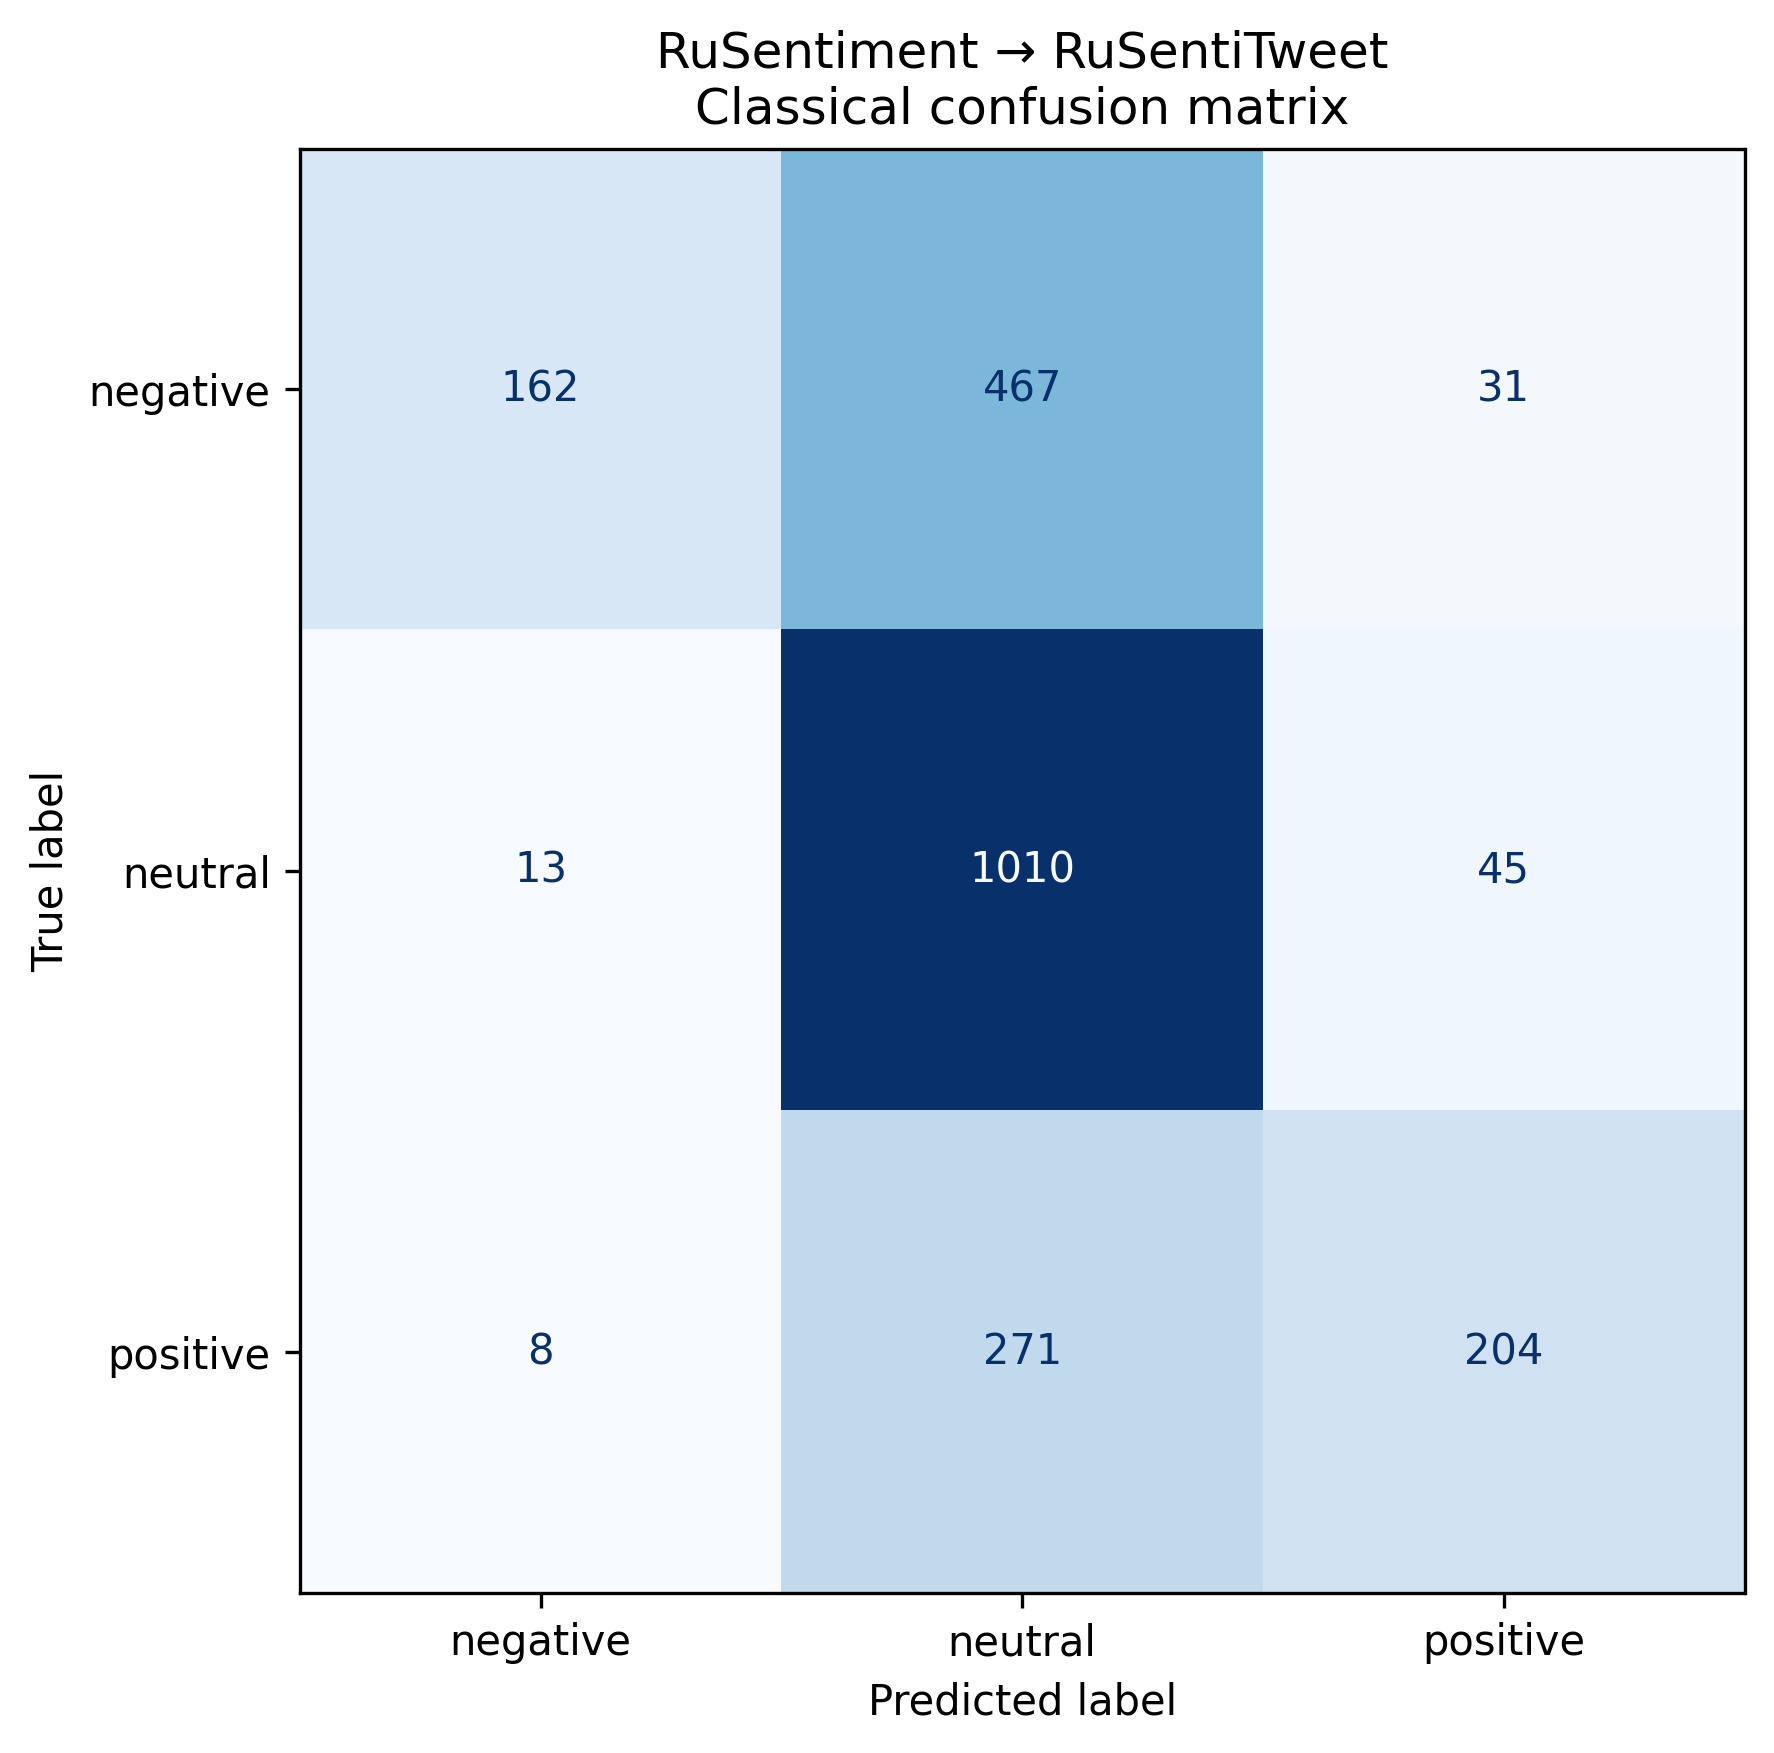

{'source_dataset': 'RuSentiment', 'target_dataset': 'RuSentiTweet', 'model_family': 'classical', 'model': 'SGDClassifier hinge + char TF-IDF', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6223, 'precision_weighted': 0.7025, 'recall_weighted': 0.6223, 'weighted_f1': 0.578, 'macro_f1': 0.5455, 'runtime_sec': 5.6996, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.8852    0.2455    0.3843       660
     neutral     0.5778    0.9457    0.7173      1068
    positive     0.7286    0.4224    0.5347       483

    accuracy                         0.6223      2211
   macro avg     0.7305    0.5378    0.5455      2211
weighted avg     0.7025    0.6223    0.5780      2211



In [12]:
res_classical_rs_to_rst, pred_classical_rs_to_rst, rep_classical_rs_to_rst = run_classical_cross_dataset(
    source_name="RuSentiment",
    target_name="RuSentiTweet",
    source_train_df=rs_train_df,
    target_test_df=rst_test_df,
    report_filename="classification_report_rs_to_rst_classical.txt",
    figure_filename="rs_to_rst_classical_confusion_matrix.png"
)

e8_results.append(res_classical_rs_to_rst)

print(res_classical_rs_to_rst)
print(rep_classical_rs_to_rst)

In [13]:
!pip install -q transformers

In [14]:
import torch
from torch.nn.functional import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [15]:
def bert_predict_proba(texts, tokenizer, model, device, max_length=128, batch_size=32):
    all_probs = []
    texts = list(texts)

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            probs = softmax(outputs.logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

    return np.vstack(all_probs)

In [16]:
def run_bert_cross_dataset(
    source_name,
    target_name,
    model_path,
    target_test_df,
    report_filename,
    figure_filename
):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    y_test = target_test_df["label"].copy()

    start_time = time.time()
    proba = bert_predict_proba(target_test_df["text"], tokenizer, model, device)
    runtime_sec = time.time() - start_time

    pred_ids = np.argmax(proba, axis=1)
    y_pred = np.array([LABEL_ORDER[i] for i in pred_ids])

    acc = accuracy_score(y_test, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_test, y_pred, average="macro")

    report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report_text)

    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"{source_name} → {target_name}\nBERT confusion matrix")
    plt.tight_layout()
    plt.savefig(FIG_DIR / figure_filename, dpi=300, bbox_inches="tight")
    plt.show()

    result = {
        "source_dataset": source_name,
        "target_dataset": target_name,
        "model_family": "bert",
        "model": f"ruBERT-tiny2 tuned on {source_name}",
        "representation": "Tokenizer",
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "runtime_sec": round(runtime_sec, 4),
        "seed": SEED
    }

    return result, y_pred, report_text

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

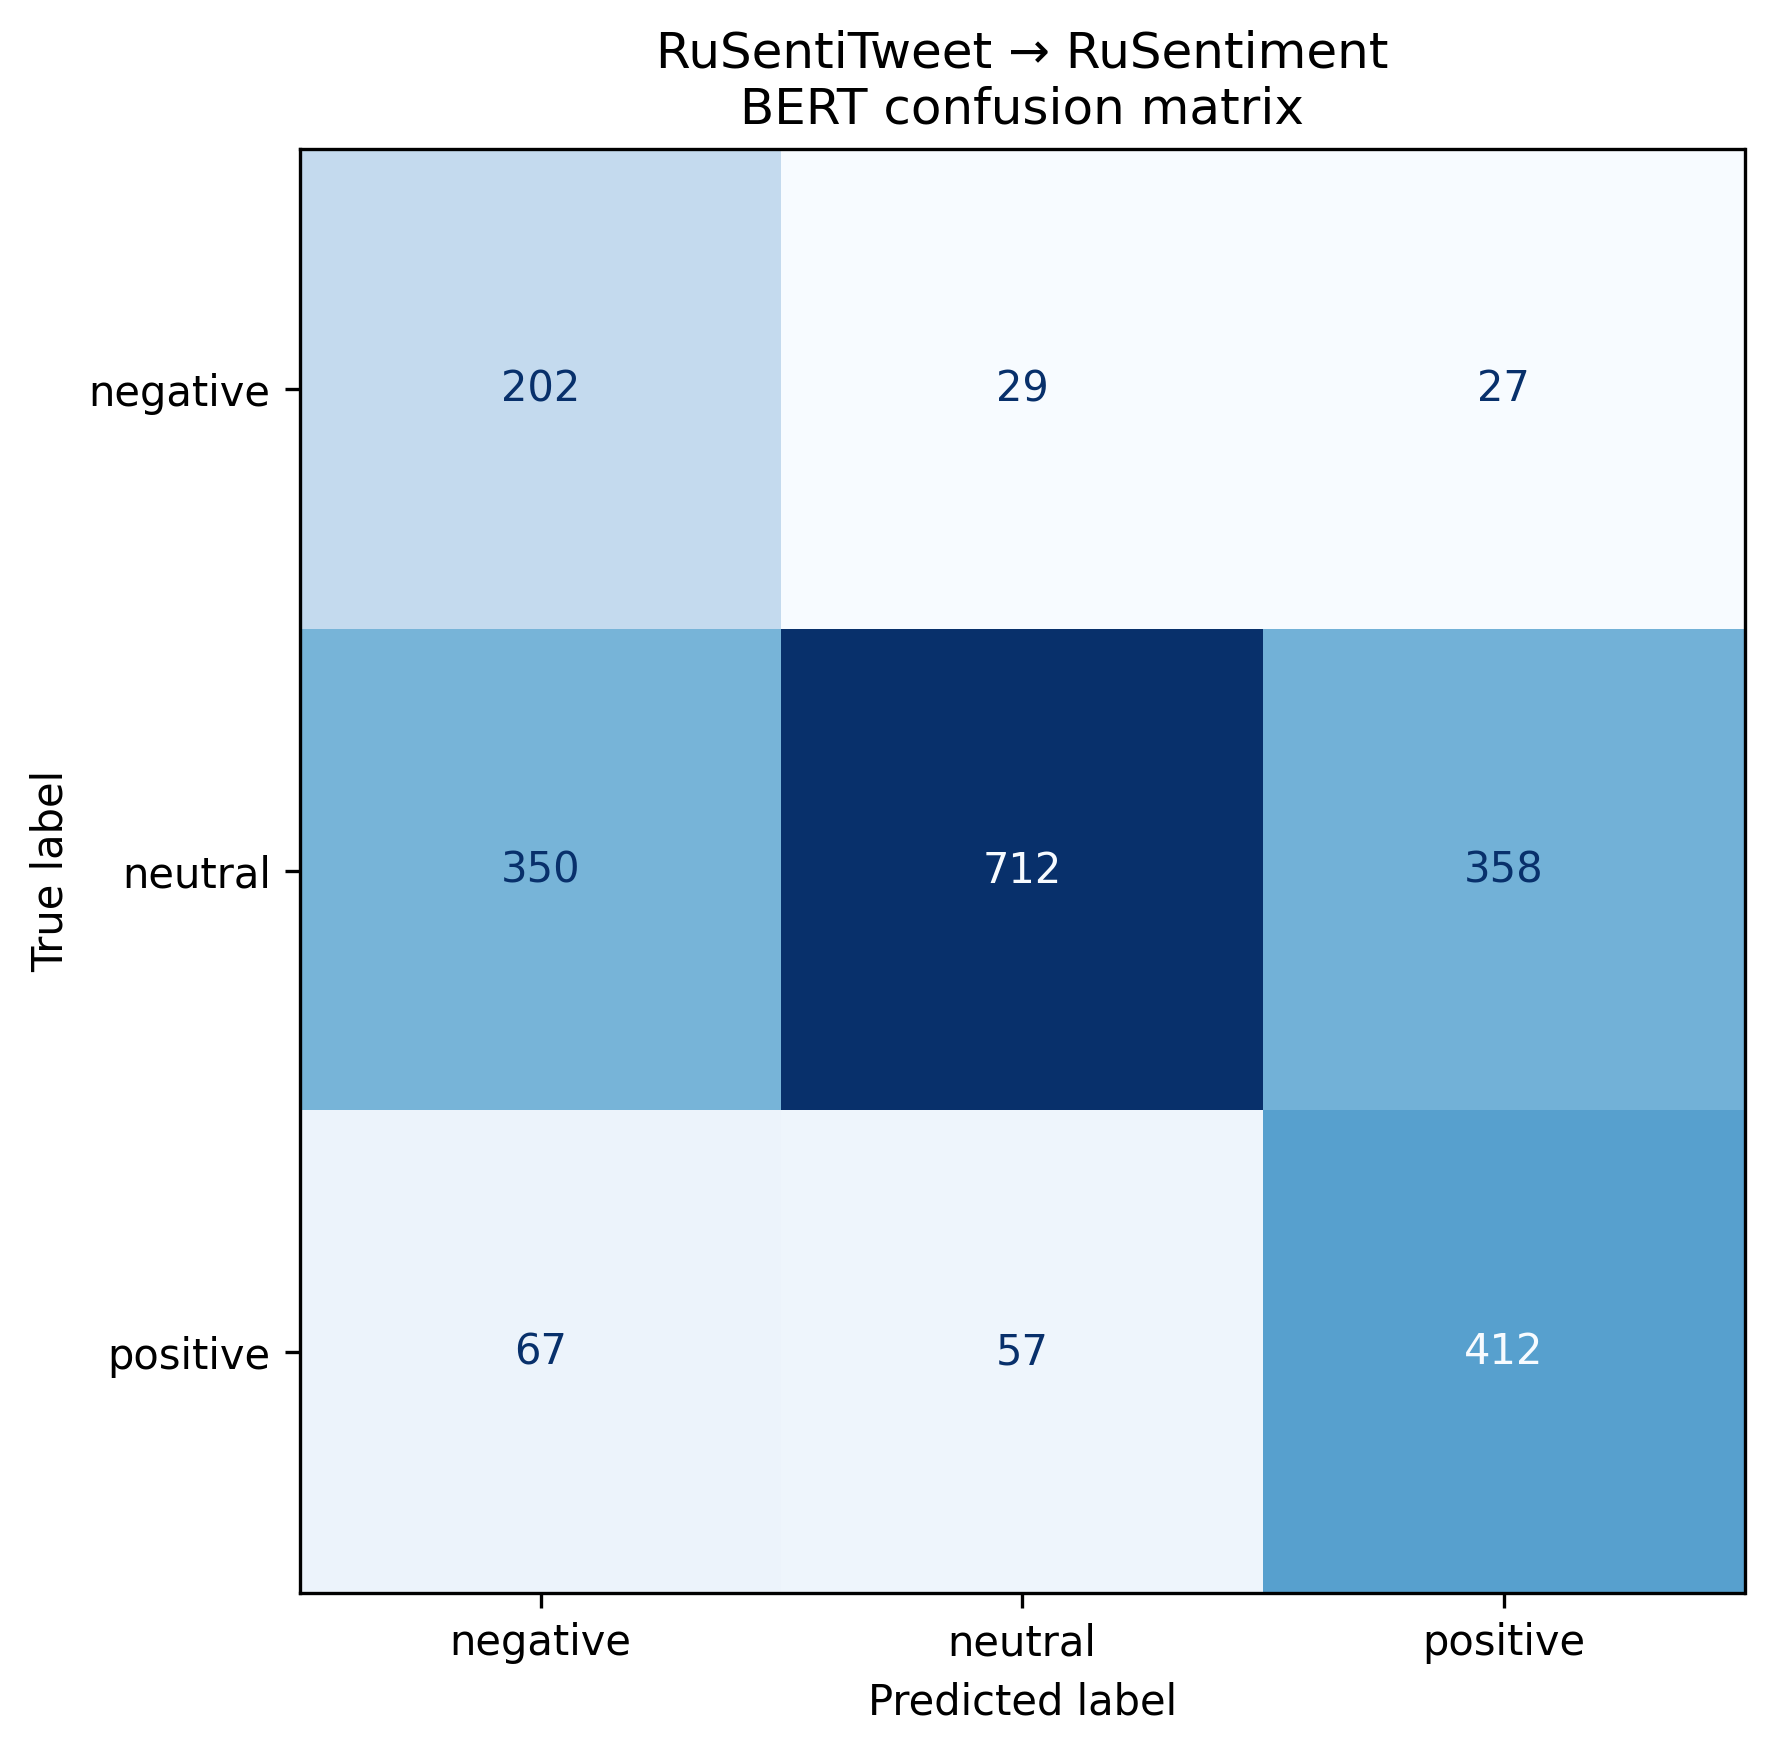

{'source_dataset': 'RuSentiTweet', 'target_dataset': 'RuSentiment', 'model_family': 'bert', 'model': 'ruBERT-tiny2 tuned on RuSentiTweet', 'representation': 'Tokenizer', 'accuracy': 0.5989, 'precision_weighted': 0.7354, 'recall_weighted': 0.5989, 'weighted_f1': 0.6151, 'macro_f1': 0.5736, 'runtime_sec': 55.4775, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.3263    0.7829    0.4607       258
     neutral     0.8922    0.5014    0.6420      1420
    positive     0.5169    0.7687    0.6182       536

    accuracy                         0.5989      2214
   macro avg     0.5785    0.6843    0.5736      2214
weighted avg     0.7354    0.5989    0.6151      2214



In [17]:
res_bert_rst_to_rs, pred_bert_rst_to_rs, rep_bert_rst_to_rs = run_bert_cross_dataset(
    source_name="RuSentiTweet",
    target_name="RuSentiment",
    model_path=RUSENTITWEET_BERT_PATH,
    target_test_df=rs_test_df,
    report_filename="classification_report_rst_to_rs_bert.txt",
    figure_filename="rst_to_rs_bert_confusion_matrix.png"
)

e8_results.append(res_bert_rst_to_rs)

print(res_bert_rst_to_rs)
print(rep_bert_rst_to_rs)

Loading weights:   0%|          | 0/57 [00:01<?, ?it/s]

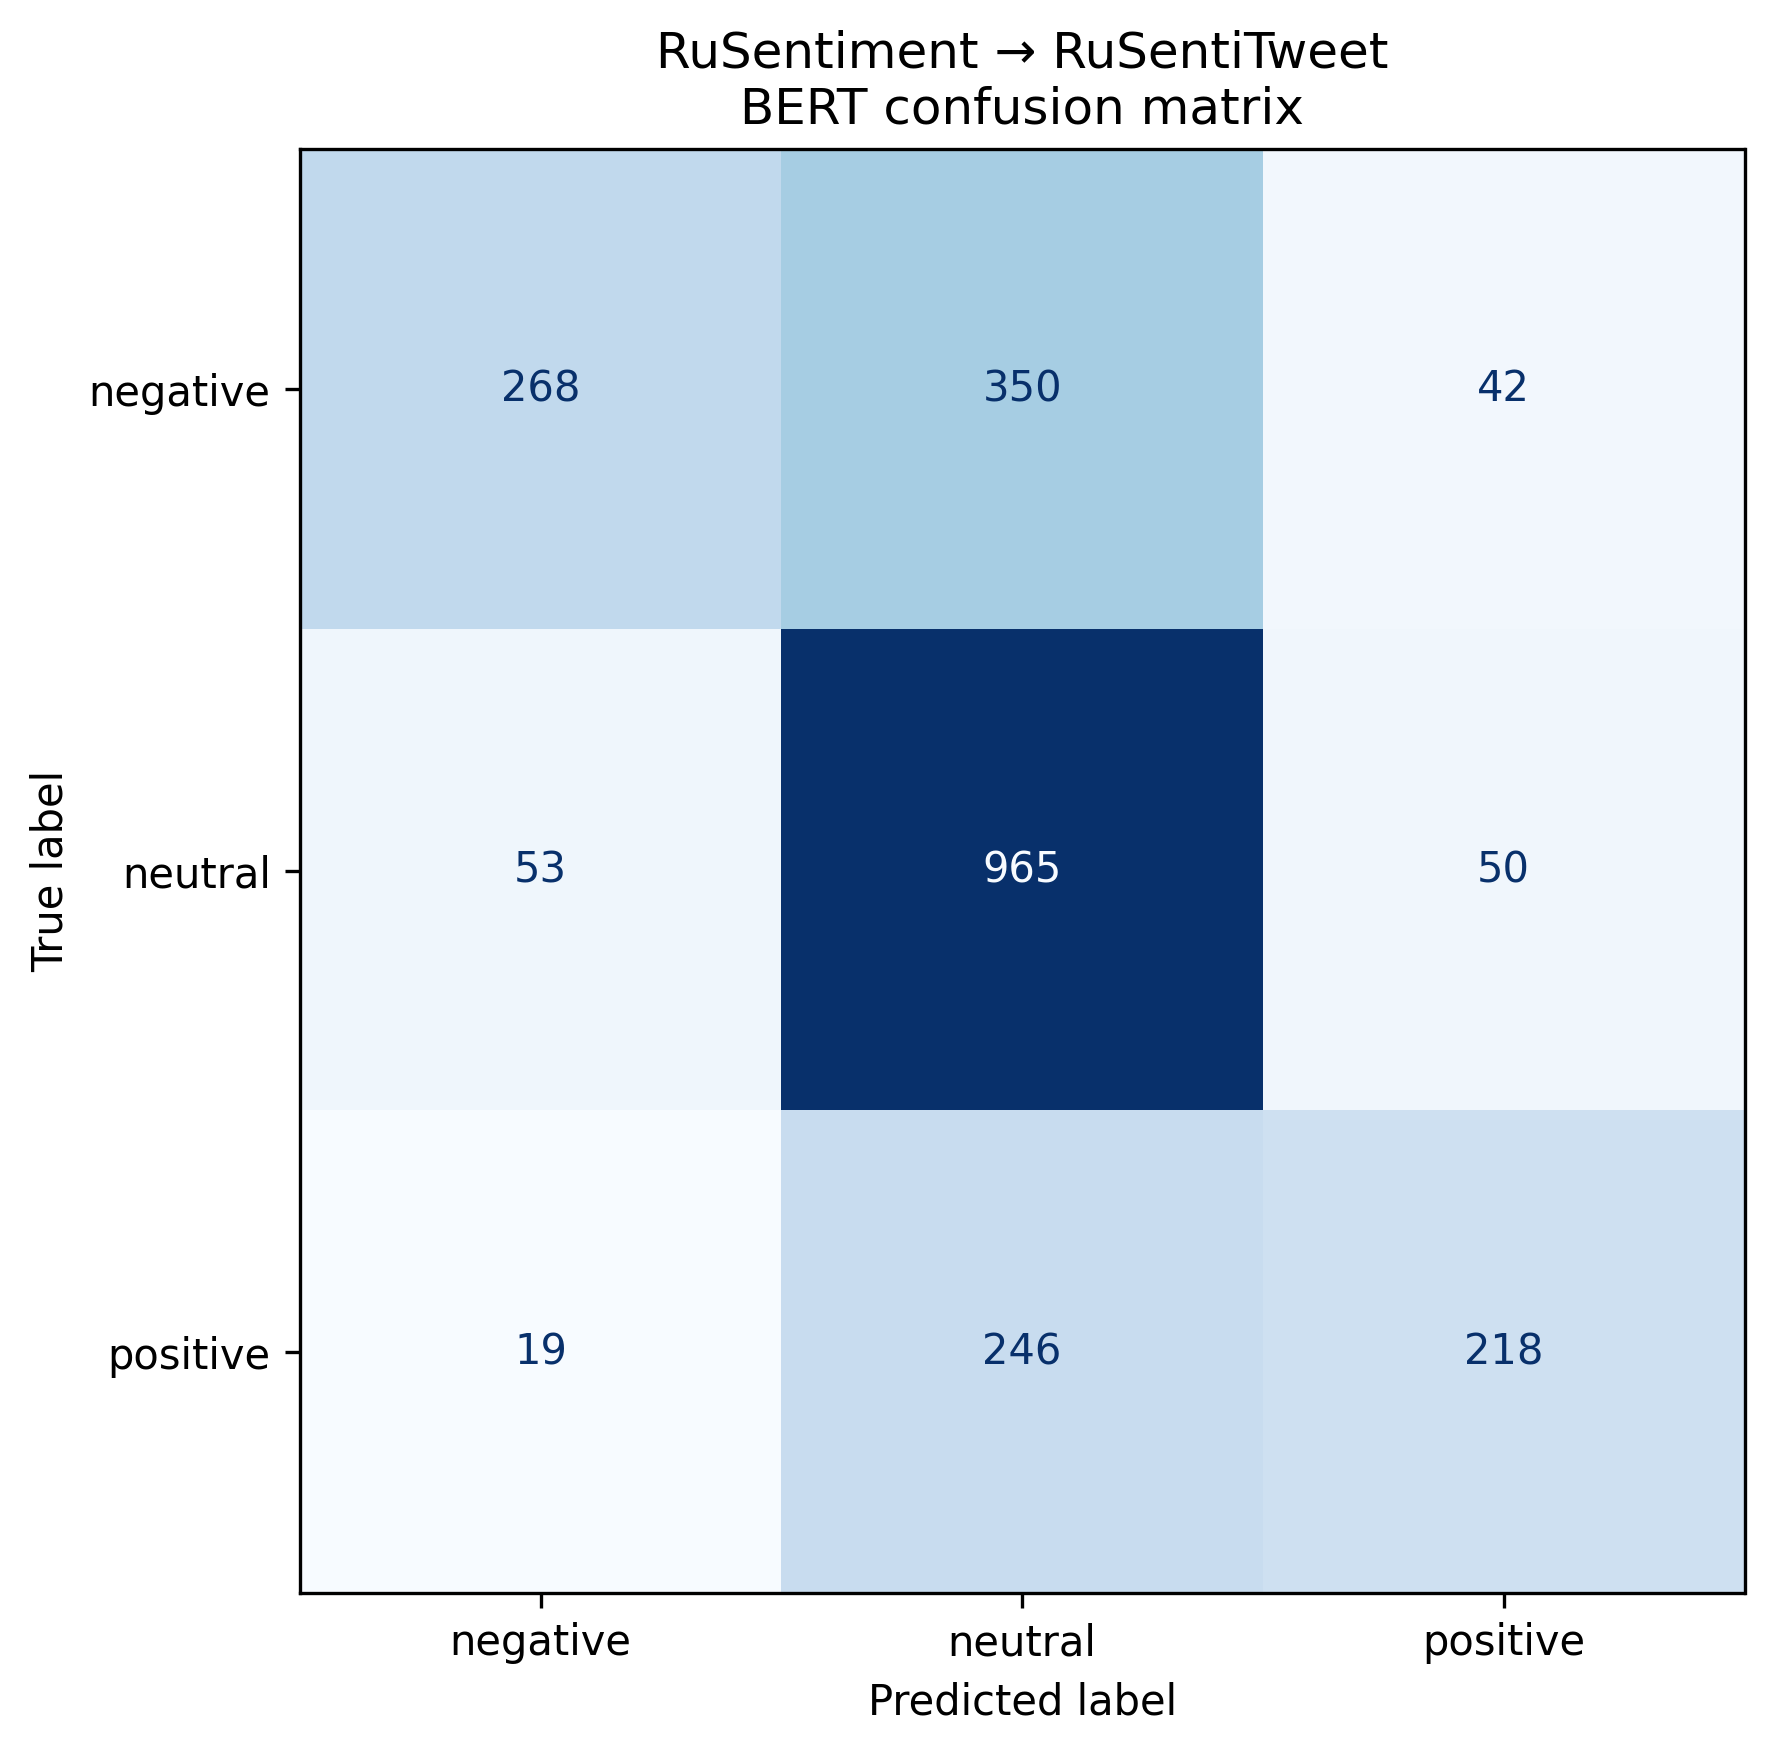

{'source_dataset': 'RuSentiment', 'target_dataset': 'RuSentiTweet', 'model_family': 'bert', 'model': 'ruBERT-tiny2 tuned on RuSentiment', 'representation': 'Tokenizer', 'accuracy': 0.6563, 'precision_weighted': 0.6875, 'recall_weighted': 0.6563, 'weighted_f1': 0.6347, 'macro_f1': 0.6066, 'runtime_sec': 54.9708, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.7882    0.4061    0.5360       660
     neutral     0.6182    0.9036    0.7341      1068
    positive     0.7032    0.4513    0.5498       483

    accuracy                         0.6563      2211
   macro avg     0.7032    0.5870    0.6066      2211
weighted avg     0.6875    0.6563    0.6347      2211



In [27]:
res_bert_rs_to_rst, pred_bert_rs_to_rst, rep_bert_rs_to_rst = run_bert_cross_dataset(
    source_name="RuSentiment",
    target_name="RuSentiTweet",
    model_path=RUSENTIMENT_BERT_PATH,
    target_test_df=rst_test_df,
    report_filename="classification_report_rs_to_rst_bert.txt",
    figure_filename="rs_to_rst_bert_confusion_matrix.png"
)

e8_results.append(res_bert_rs_to_rst)

print(res_bert_rs_to_rst)
print(rep_bert_rs_to_rst)

In [28]:
e8_results_df = pd.DataFrame(e8_results)
e8_results_df = e8_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e8_results_df)

,source_dataset,target_dataset,model_family,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,runtime_sec,seed
0,RuSentiTweet,RuSentiment,classical,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",0.6409,0.7170,0.6409,0.6597,0.5932,1.8830,42
1,RuSentiment,RuSentiTweet,bert,ruBERT-tiny2 tuned on RuSentiment,Tokenizer,0.6563,0.6875,0.6563,0.6347,0.6066,54.9708,42
2,RuSentiTweet,RuSentiment,bert,ruBERT-tiny2 tuned on RuSentiTweet,Tokenizer,0.5989,0.7354,0.5989,0.6151,0.5736,55.4775,42
3,RuSentiment,RuSentiTweet,classical,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",0.6223,0.7025,0.6223,0.5780,0.5455,5.6996,42


In [29]:
e8_results_df.to_csv(TABLE_DIR / "e8_cross_dataset_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e8_cross_dataset_results.csv")

Saved: e8_artifacts/tables/e8_cross_dataset_results.csv


In [30]:
reference_in_domain = pd.DataFrame([
    {
        "source_dataset": "RuSentiTweet",
        "model_family": "classical",
        "weighted_f1_in_domain": 0.6741,
        "macro_f1_in_domain": 0.6517
    },
    {
        "source_dataset": "RuSentiTweet",
        "model_family": "bert",
        "weighted_f1_in_domain": 0.6958,
        "macro_f1_in_domain": 0.6810
    },
    {
        "source_dataset": "RuSentiment",
        "model_family": "classical",
        "weighted_f1_in_domain": 0.7660,
        "macro_f1_in_domain": 0.6686
    },
    {
        "source_dataset": "RuSentiment",
        "model_family": "bert",
        "weighted_f1_in_domain": 0.7698,
        "macro_f1_in_domain": 0.7083
    }
])

transfer_df = e8_results_df.merge(
    reference_in_domain,
    on=["source_dataset", "model_family"],
    how="left"
)

transfer_df["weighted_f1_drop_vs_in_domain"] = (
    transfer_df["weighted_f1"] - transfer_df["weighted_f1_in_domain"]
).round(4)

transfer_df["macro_f1_drop_vs_in_domain"] = (
    transfer_df["macro_f1"] - transfer_df["macro_f1_in_domain"]
).round(4)

display(transfer_df)

,source_dataset,target_dataset,model_family,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,runtime_sec,seed,weighted_f1_in_domain,macro_f1_in_domain,weighted_f1_drop_vs_in_domain,macro_f1_drop_vs_in_domain
0,RuSentiTweet,RuSentiment,classical,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",0.6409,0.7170,0.6409,0.6597,0.5932,1.8830,42,0.6741,0.6517,-0.0144,-0.0585
1,RuSentiment,RuSentiTweet,bert,ruBERT-tiny2 tuned on RuSentiment,Tokenizer,0.6563,0.6875,0.6563,0.6347,0.6066,54.9708,42,0.7698,0.7083,-0.1351,-0.1017
2,RuSentiTweet,RuSentiment,bert,ruBERT-tiny2 tuned on RuSentiTweet,Tokenizer,0.5989,0.7354,0.5989,0.6151,0.5736,55.4775,42,0.6958,0.6810,-0.0807,-0.1074
3,RuSentiment,RuSentiTweet,classical,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",0.6223,0.7025,0.6223,0.5780,0.5455,5.6996,42,0.7660,0.6686,-0.1880,-0.1231


In [31]:
transfer_df.to_csv(TABLE_DIR / "e8_transfer_drop_vs_in_domain.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e8_transfer_drop_vs_in_domain.csv")

Saved: e8_artifacts/tables/e8_transfer_drop_vs_in_domain.csv


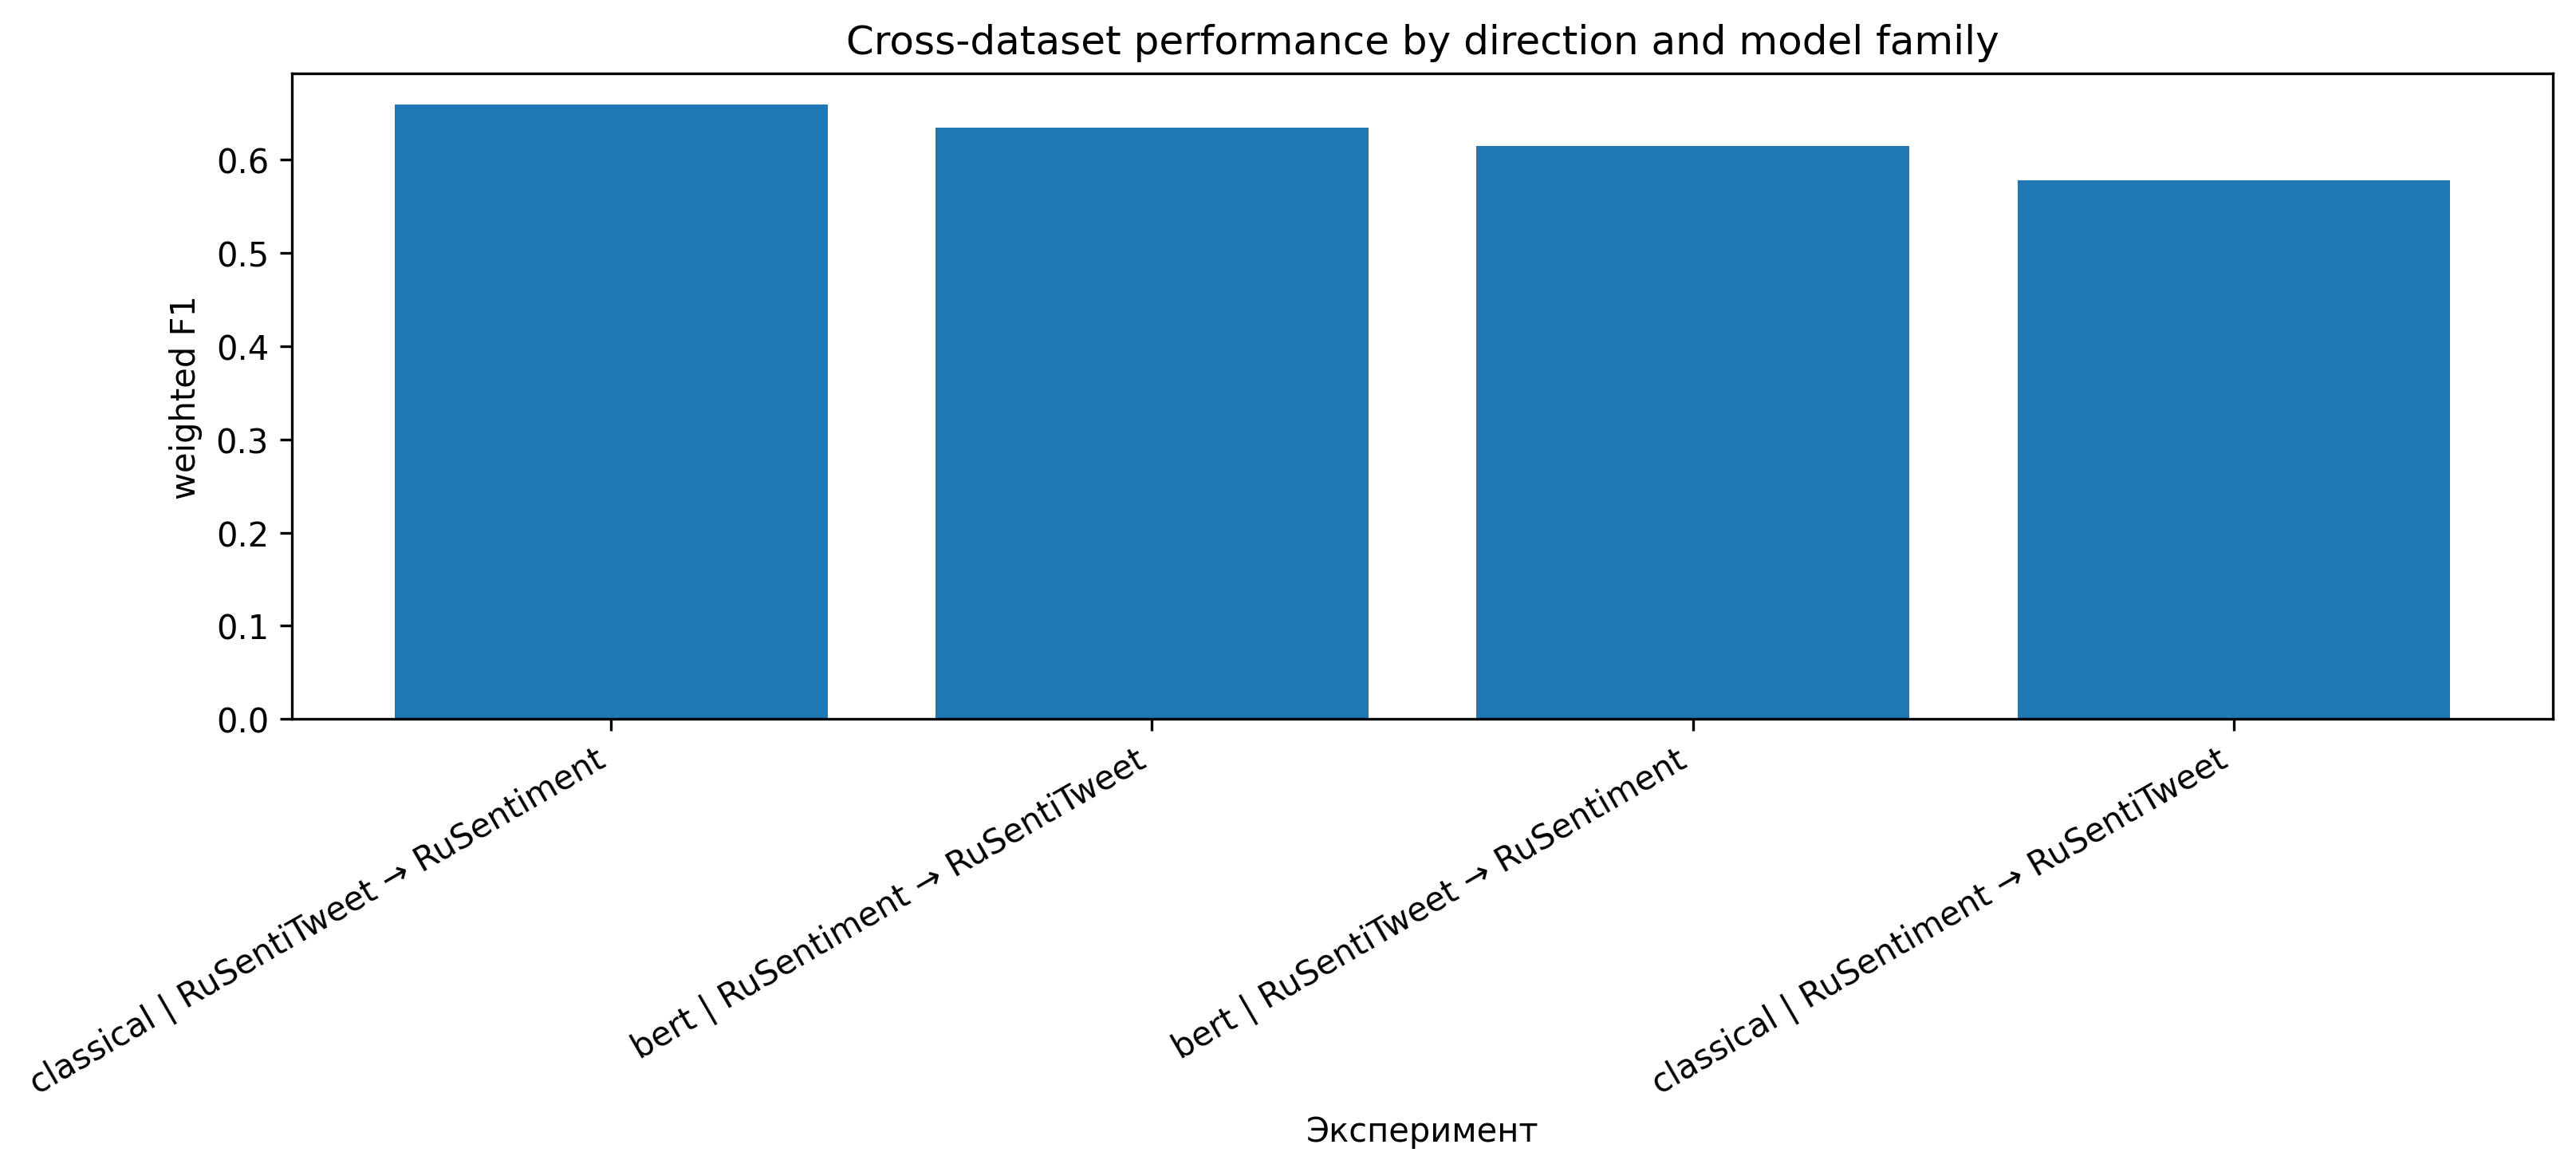

In [32]:
plot_df = e8_results_df.copy()
plot_df["label"] = plot_df["model_family"] + " | " + plot_df["source_dataset"] + " → " + plot_df["target_dataset"]

plt.figure(figsize=(11, 5), dpi=300)
plt.bar(plot_df["label"], plot_df["weighted_f1"])
plt.title("Cross-dataset performance by direction and model family")
plt.xlabel("Эксперимент")
plt.ylabel("weighted F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e8_cross_dataset_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

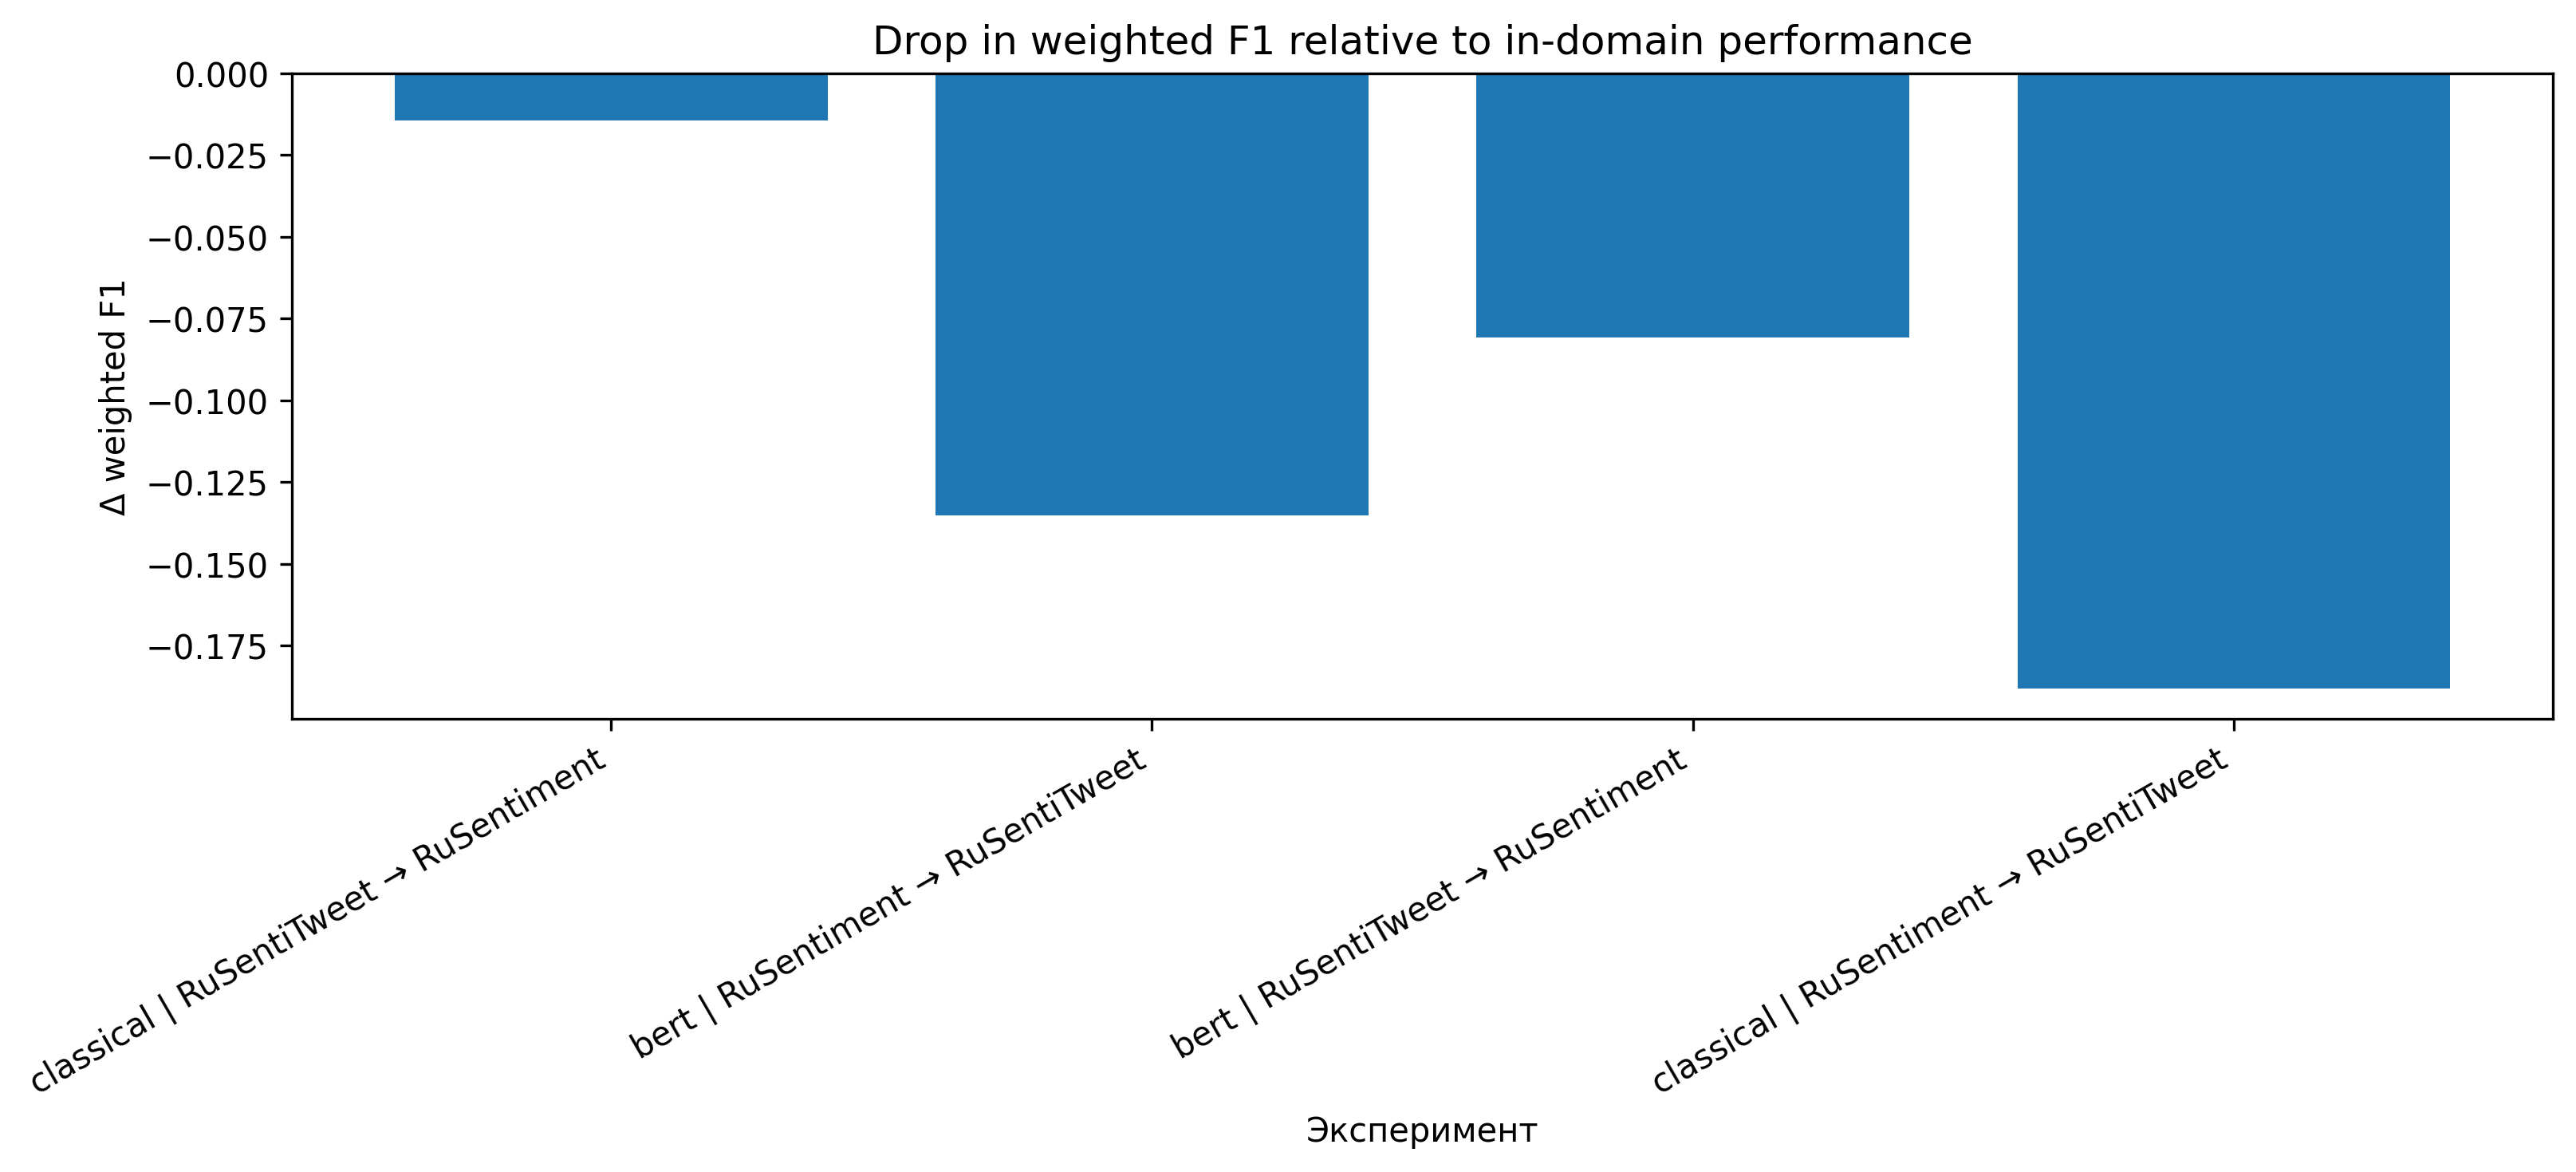

In [33]:
drop_plot_df = transfer_df.copy()
drop_plot_df["label"] = drop_plot_df["model_family"] + " | " + drop_plot_df["source_dataset"] + " → " + drop_plot_df["target_dataset"]

plt.figure(figsize=(11, 5), dpi=300)
plt.bar(drop_plot_df["label"], drop_plot_df["weighted_f1_drop_vs_in_domain"])
plt.title("Drop in weighted F1 relative to in-domain performance")
plt.xlabel("Эксперимент")
plt.ylabel("Δ weighted F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e8_transfer_drop_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
experiment_ids = [f"E8-{i+1}" for i in range(len(e8_results_df))]

e8_registry = e8_results_df.copy()
e8_registry.insert(0, "experiment_id", experiment_ids)
e8_registry["status"] = "completed"

display(e8_registry)

,experiment_id,source_dataset,target_dataset,model_family,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,runtime_sec,seed,status
0,E8-1,RuSentiTweet,RuSentiment,classical,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",0.6409,0.7170,0.6409,0.6597,0.5932,1.8830,42,completed
1,E8-2,RuSentiment,RuSentiTweet,bert,ruBERT-tiny2 tuned on RuSentiment,Tokenizer,0.6563,0.6875,0.6563,0.6347,0.6066,54.9708,42,completed
2,E8-3,RuSentiTweet,RuSentiment,bert,ruBERT-tiny2 tuned on RuSentiTweet,Tokenizer,0.5989,0.7354,0.5989,0.6151,0.5736,55.4775,42,completed
3,E8-4,RuSentiment,RuSentiTweet,classical,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",0.6223,0.7025,0.6223,0.5780,0.5455,5.6996,42,completed


In [35]:
e8_registry.to_csv(TABLE_DIR / "e8_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e8_experiment_registry.csv")

Saved: e8_artifacts/tables/e8_experiment_registry.csv


In [26]:
best_cross_row = e8_results_df.iloc[0]

e8_summary = f"""
E8 CROSS-DATASET SUMMARY

Goal:
Evaluate transferability of models between RuSentiTweet and RuSentiment.

Directions:
- RuSentiTweet -> RuSentiment
- RuSentiment -> RuSentiTweet

Models:
- Classical: SGDClassifier hinge + char TF-IDF (3,5)
- BERT: tuned ruBERT-tiny2

Best cross-dataset result:
source_dataset = {best_cross_row["source_dataset"]}
target_dataset = {best_cross_row["target_dataset"]}
model = {best_cross_row["model"]}
weighted_f1 = {best_cross_row["weighted_f1"]}
macro_f1 = {best_cross_row["macro_f1"]}

Full ranking:
{e8_results_df[["source_dataset", "target_dataset", "model_family", "weighted_f1", "macro_f1"]].to_string(index=False)}

Transfer drop table:
{transfer_df[["source_dataset", "target_dataset", "model_family", "weighted_f1", "weighted_f1_in_domain", "weighted_f1_drop_vs_in_domain"]].to_string(index=False)}
"""

with open(LOG_DIR / "e8_summary.txt", "w", encoding="utf-8") as f:
    f.write(e8_summary)

print("Saved:", LOG_DIR / "e8_summary.txt")

Saved: e8_artifacts/logs/e8_summary.txt
